### IMS dataset

- Three (3) data sets are included in the data packet (IMS-Rexnord Bearing Data.zip).
- Each data set describes a test-to-failure experiment.
- Each data set consists of individual files that are 1-second vibration signal snapshots recorded at specific intervals.
- Each file consists of 20,480 points with the sampling rate set at 20 kHz.
- The file name indicates when the data was collected. Each record (row) in the data file is a data point

In [1]:
import os

os.chdir('..')
os.getcwd()

'c:\\Users\\chouybat\\repositories\\phm-101'

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from dotenv import load_dotenv

load_dotenv()
data_root = Path(os.environ["DATA_ROOT"])

ims_dir  = data_root / "time_series" / "bearing" / "ims"
first_dataset_path = ims_dir / "1st_test"
second_dataset_path = ims_dir / "2nd_test"
third_dataset_path = ims_dir / "3rd_test"

### visualization

In [8]:
filename = '2004.02.12.10.32.39'
dataset=pd.read_csv(os.path.join(second_dataset_path, filename), sep='\t',header=None)

In [4]:
dataset

,0,1,2,3
0,-0.049,-0.071,-0.132,-0.010
1,-0.042,-0.073,-0.007,-0.105
2,0.015,0.000,0.007,0.000
3,-0.051,0.020,-0.002,0.100
4,-0.107,0.010,0.127,0.054
...,...,...,...,...
20475,0.049,-0.051,-0.039,-0.044
20476,0.037,0.061,0.115,0.007
20477,-0.012,0.007,0.056,-0.007
20478,-0.012,0.093,0.017,-0.044


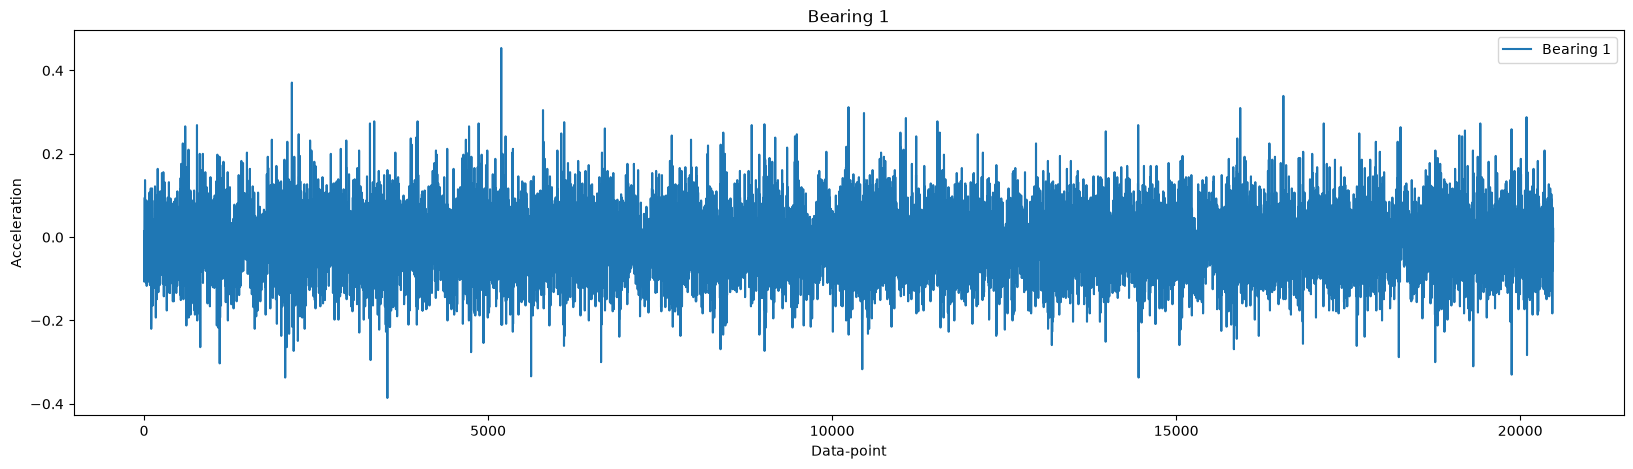

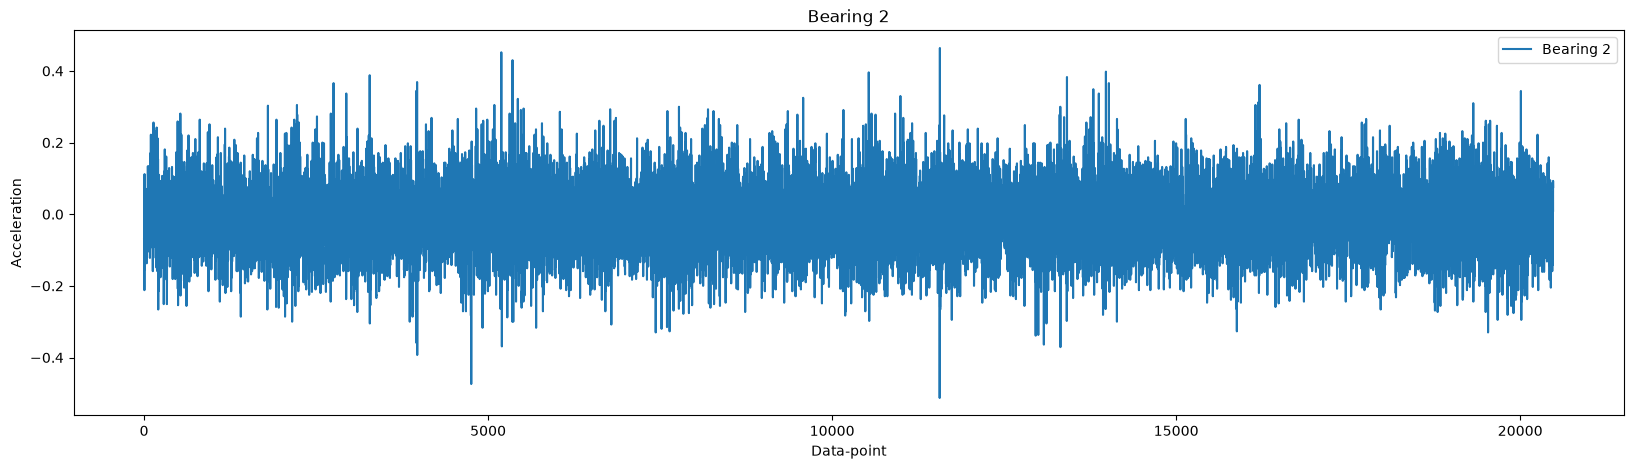

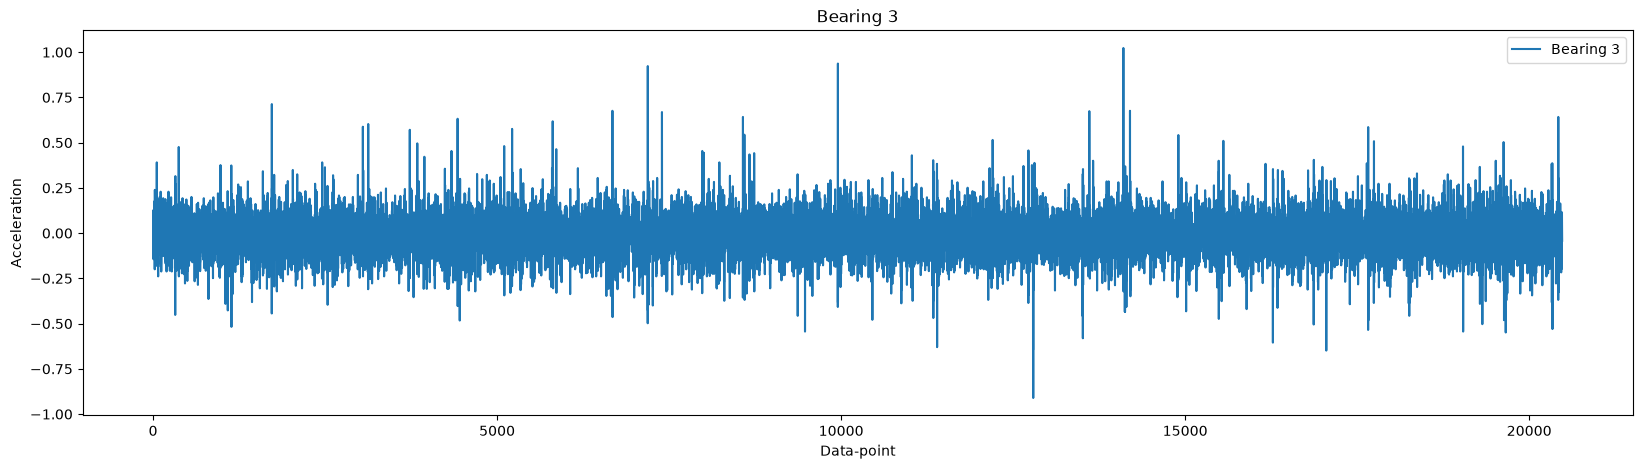

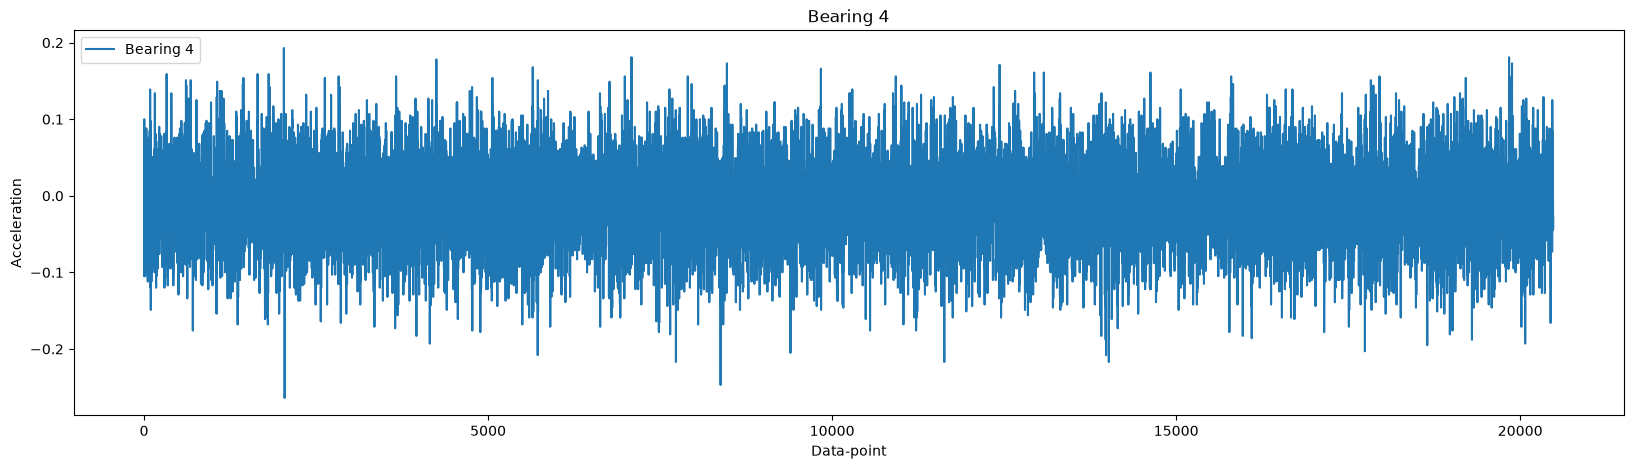

In [9]:
for i in [0,1,2,3]:

    df_bearing=np.array(dataset.iloc[:,i])

    plt.figure(figsize=(20, 5))
    plt.plot(df_bearing)

    plt.legend([f'Bearing {i+1}'])

    plt.xlabel("Data-point")
    plt.ylabel("Acceleration")
    plt.title(f'Bearing {i+1}')
    plt.show()



### feature extraction

We will calculate following time domain features.

- Maximum value
- Minimum value
- Mean value
- Standard deviation (Unbiased std)
- Root mean square value (RMS)
- Skewness
- Kurtosis
- Crest factor = Max / RMS
- Form factor = RMS / Mean


In [3]:
def compute_skewness(x: np.ndarray) -> float:
    """Utility function to compute the skewness of a signal."""
    n = len(x)
    third_moment = np.sum((x - np.mean(x))**3) / n
    s_3 = np.std(x, ddof = 1) ** 3
    return third_moment/s_3

def compute_kurtosis(x: np.ndarray) -> float:
    """Utility function to compute the kurtosis of a signal."""
    n = len(x)
    fourth_moment = np.sum((x - np.mean(x))**4) / n
    s_4 = np.std(x, ddof = 1) ** 4
    return fourth_moment / s_4 - 3

In [44]:
time_feature_matrix=pd.DataFrame()

test_set_path = third_dataset_path
bearing_no=4 # Provide the Bearing number [1,2,3,4] of the Test set

for filename in os.listdir(test_set_path):

    dataset=pd.read_csv(os.path.join(test_set_path, filename), sep='\t',header=None)

    bearing_data = np.array(dataset.iloc[:,bearing_no-1])

    feature_matrix=np.zeros((1,9))
    temp = bearing_data
    feature_matrix[0,0] = np.max(temp)
    feature_matrix[0,1] = np.min(temp)
    feature_matrix[0,2] = np.mean(temp)
    feature_matrix[0,3] = np.std(temp, ddof = 1)
    feature_matrix[0,4] = np.sqrt(np.mean(temp ** 2))
    feature_matrix[0,5] = compute_skewness(temp)
    feature_matrix[0,6] = compute_kurtosis(temp)
    feature_matrix[0,7] = feature_matrix[0,0]/feature_matrix[0,4]
    feature_matrix[0,8] = feature_matrix[0,4]/feature_matrix[0,2]

    df = pd.DataFrame(feature_matrix)
    df.index=[filename[:-3]]

    time_feature_matrix = pd.concat([time_feature_matrix, df], axis=0)

In [45]:
# renaming
time_feature_matrix.columns = ['Max','Min','Mean','Std','RMS','Skewness','Kurtosis','Crest Factor','Form Factor']
time_feature_matrix.index = pd.to_datetime(time_feature_matrix.index, format='%Y.%m.%d.%H.%M')

time_feature_matrix = time_feature_matrix.sort_index()

time_feature_matrix

,Max,Min,Mean,Std,RMS,Skewness,Kurtosis,Crest Factor,Form Factor
2004-03-04 09:27:00,0.254,-0.303,-0.004331,0.055325,0.055493,0.038845,0.559706,4.577189,-12.813293
2004-03-04 09:32:00,0.212,-0.249,-0.006725,0.052926,0.053351,0.013904,0.355708,3.973709,-7.932665
2004-03-04 09:42:00,0.278,-0.278,-0.003200,0.052607,0.052703,0.034235,0.477955,5.274828,-16.469227
2004-03-04 09:52:00,0.269,-0.300,-0.004379,0.054671,0.054844,0.007403,0.341732,4.904798,-12.524926
2004-03-04 10:02:00,0.227,-0.247,-0.003443,0.053805,0.053914,0.023473,0.261460,4.210398,-15.660536
...,...,...,...,...,...,...,...,...,...
2004-04-18 02:02:00,0.867,-0.955,-0.003682,0.248059,0.248081,-0.026558,0.022271,3.494830,-67.379632
2004-04-18 02:12:00,0.918,-0.813,-0.003608,0.253635,0.253654,0.104431,-0.257887,3.619096,-70.304147
2004-04-18 02:22:00,1.082,-1.104,-0.003425,0.279849,0.279863,0.002889,0.030199,3.866172,-81.701455
2004-04-18 02:32:00,0.881,-0.969,-0.003452,0.282160,0.282174,-0.108601,-0.486148,3.122183,-81.743400


In [46]:
# save feature matrix to csv
feature_store_path = Path("data/ims_features")
time_feature_matrix.to_csv(feature_store_path / f'test3_bearing_{bearing_no}_time_features.csv', index=True)

### features visualization

In [ ]:
feature_store_path = Path("data/ims_features")

df1 = pd.read_csv(feature_store_path / 'test1_bearing_1_time_features.csv',index_col='Unnamed: 0')
df2 = pd.read_csv(feature_store_path / 'test1_bearing_2_time_features.csv',index_col='Unnamed: 0')
df3 = pd.read_csv(feature_store_path / 'test1_bearing_3_time_features.csv',index_col='Unnamed: 0')
df4 = pd.read_csv(feature_store_path / 'test1_bearing_4_time_features.csv',index_col='Unnamed: 0')

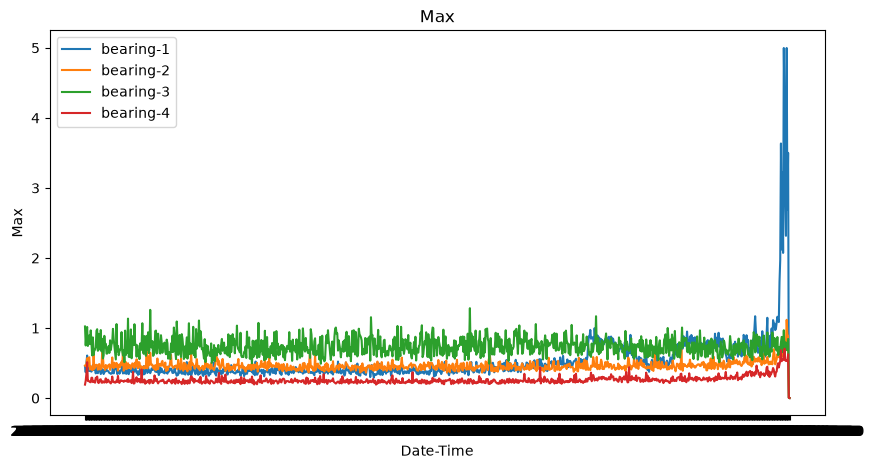

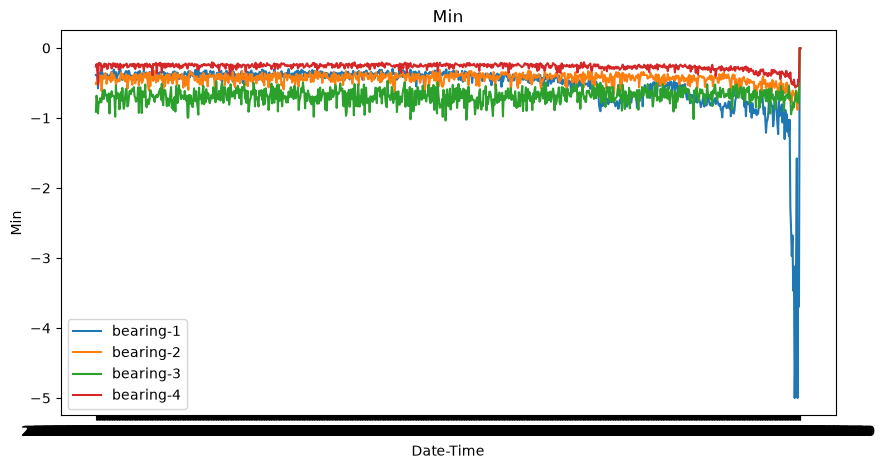

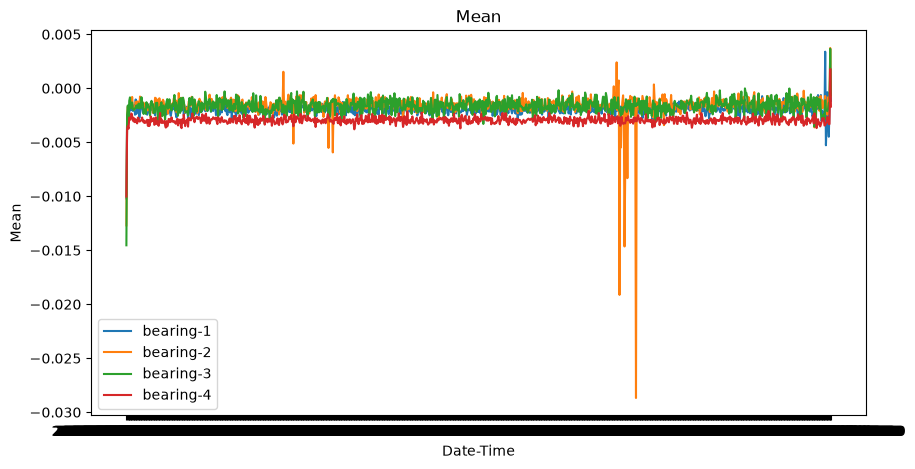

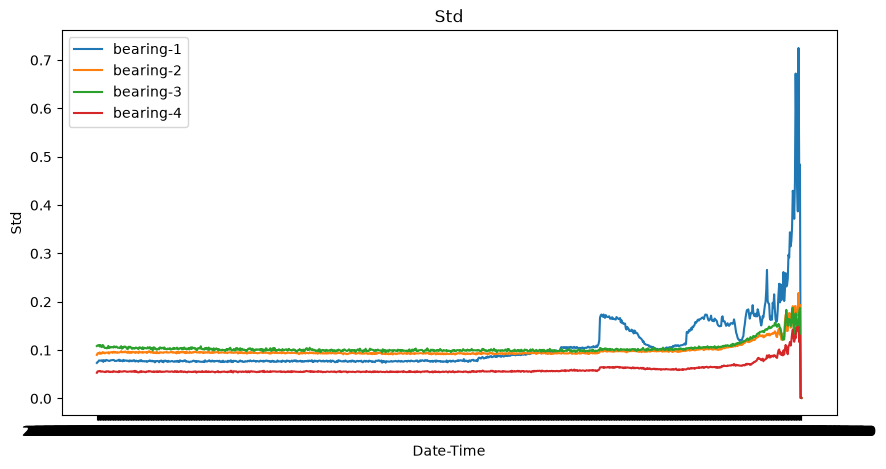

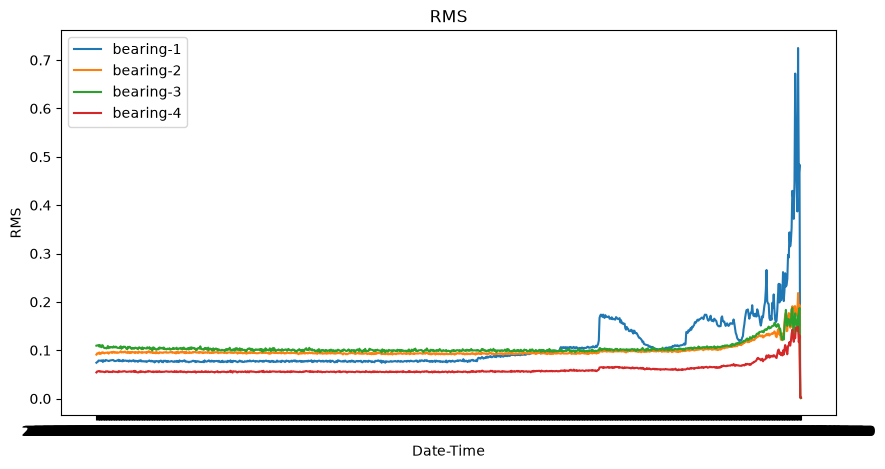

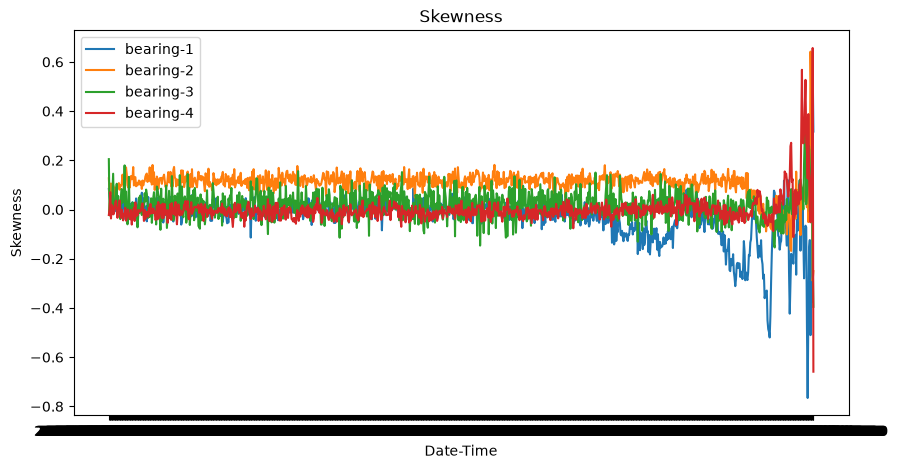

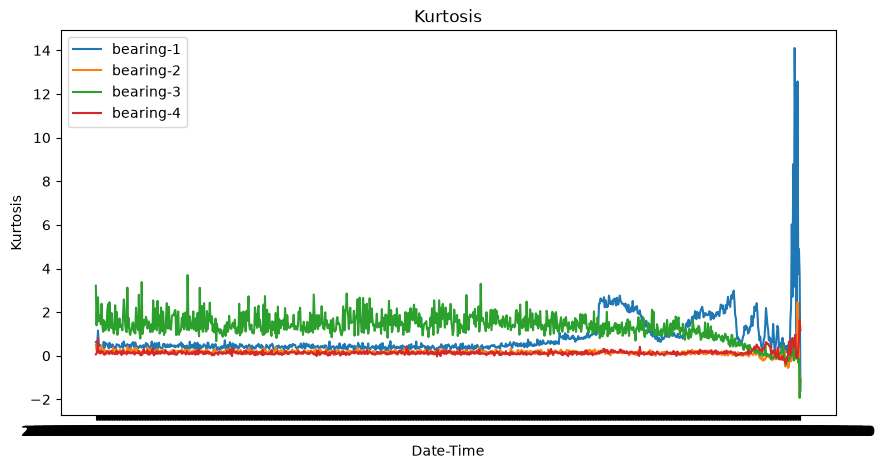

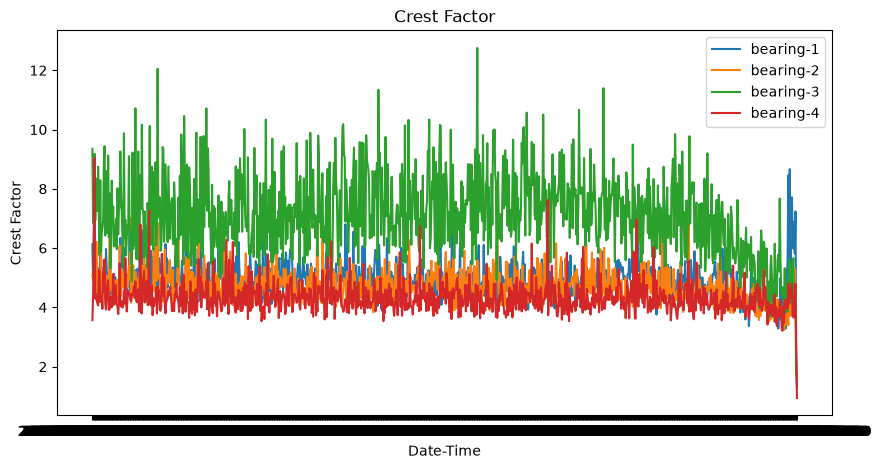

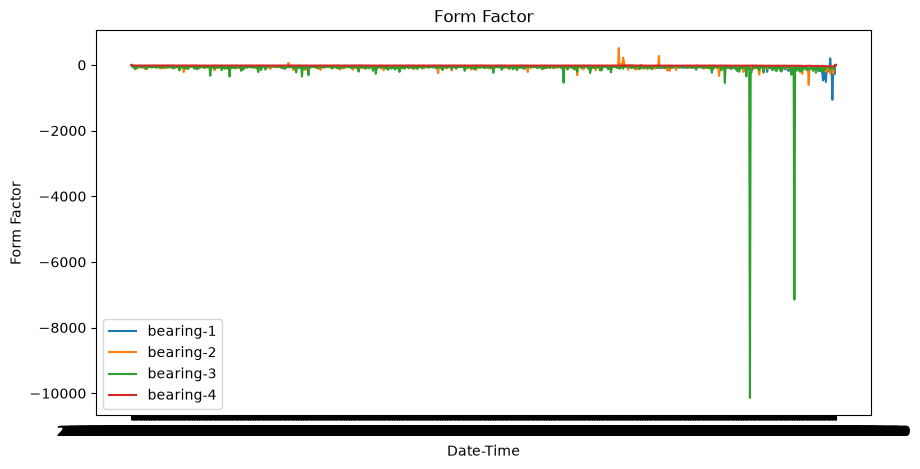

In [44]:
for col in (df1.columns):
    plt.figure(figsize=(10, 5))
    plt.plot(df1.index,df1[col])
    plt.plot(df1.index,df2[col])
    plt.plot(df1.index,df3[col])
    plt.plot(df1.index,df4[col])

    plt.legend(['bearing-1','bearing-2','bearing-3','bearing-4'])

    plt.xlabel("Date-Time")
    plt.ylabel(col)
    plt.title(col)
    plt.show()